# Exploratory Data Analysis - PART 1
## Cardiovascular Disease Database Analysis

This notebook performs the first half of comprehensive EDA on the healthcare database containing:
- **seniors**: unique seniors
- **measurements**: vital signs (HR, Temperature, SpO₂, Steps, Blood Pressure)
- **medicines**: medicine data per senior
- **diseases**: disease data per senior
- **alerts**: SOS alerts and notes

### Outline
1. Database Connection & Overview
2. Global Dataset Understanding
3. Missing Values & Duplicates Analysis
4. Distribution Analysis of Vital Signs
5. Time-Series Structure & Sampling Density


In [6]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


## 1. Database Connection & Overview

In [3]:
DB_PATH = '../db/hrp_data.db'

try:
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
except Exception as e:
    print(f"Connection failed: {e}")
    raise

In [4]:
# Get all table names
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
table_names = [t[0] for t in tables]

print(f"\nAvailable tables: {table_names}")


Available tables: ['measurements', 'sqlite_sequence', 'medical_info', 'alerts', 'seniors', 'diseases', 'medicines', 'senior_diseases', 'senior_medicines']


In [4]:
# Test connection and get row counts
print("\n" + "="*60)
print("TABLE OVERVIEW - Row Counts")
print("="*60)

table_info = {}
for table in table_names:
    cursor.execute(f"SELECT COUNT(*) FROM {table}")
    count = cursor.fetchone()[0]
    table_info[table] = count
    print(f"{table:20} | {count:>12,} rows")

# Get unique seniors in measurements table
cursor.execute("SELECT COUNT(DISTINCT senior_id) FROM measurements")
unique_seniors_measurements = cursor.fetchone()[0]
print(f"\nUnique seniors in measurements: {unique_seniors_measurements:,}")


TABLE OVERVIEW - Row Counts
measurements         |   18,033,186 rows
sqlite_sequence      |            3 rows
medical_info         |        7,129 rows
alerts               |        1,092 rows
seniors              |       11,908 rows
diseases             |          161 rows
medicines            |        1,626 rows
senior_diseases      |       41,879 rows
senior_medicines     |       41,699 rows

Unique seniors in measurements: 11,908


In [5]:
# Get schema information for all tables
print("\n" + "="*60)
print("TABLE SCHEMAS")
print("="*60)

for table in table_names:
    cursor.execute(f"PRAGMA table_info({table})")
    columns = cursor.fetchall()
    print(f"\n{table}:")
    for col in columns:
        col_id, col_name, col_type, notnull, default, pk = col
        nullable = "NOT NULL" if notnull else "NULLABLE"
        print(f"  - {col_name:20} {col_type:15} {nullable}")



TABLE SCHEMAS

measurements:
  - id                   INTEGER         NULLABLE
  - senior_id            INTEGER         NOT NULL
  - value                REAL            NULLABLE
  - sbp                  REAL            NULLABLE
  - dbp                  REAL            NULLABLE
  - date                 TIMESTAMP       NOT NULL
  - type                 TEXT            NOT NULL

sqlite_sequence:
  - name                                 NULLABLE
  - seq                                  NULLABLE

medical_info:
  - senior_id            INTEGER         NULLABLE
  - disease_names        TEXT            NULLABLE
  - medicine_names       TEXT            NULLABLE

alerts:
  - senior_id            INTEGER         NULLABLE
  - alert_date           TIMESTAMP       NULLABLE
  - sos_note             TEXT            NULLABLE

seniors:
  - id                   INTEGER         NULLABLE

diseases:
  - id                   INTEGER         NULLABLE
  - disease_name         TEXT            NOT NULL

medici

In [5]:
# Load all tables
df_measurements = pd.read_sql_query("SELECT * FROM measurements", conn)
df_measurements['date'] = pd.to_datetime(df_measurements['date'])
df_alerts = pd.read_sql_query("SELECT * FROM alerts", conn)
df_diseases = pd.read_sql_query("SELECT * FROM diseases", conn)
df_medicines = pd.read_sql_query("SELECT * FROM medicines", conn)
df_seniors = pd.read_sql_query("SELECT * FROM seniors", conn)

## 2. Global Dataset Understanding

### 2.1 Measurement Type Distribution


MEASUREMENT COUNTS BY TYPE
type
Heartrate        4074735
BloodPressure    4074731
Temperature      4057151
Saturation       3250993
Steps            2575576
Name: count, dtype: int64

Total unique types: 5


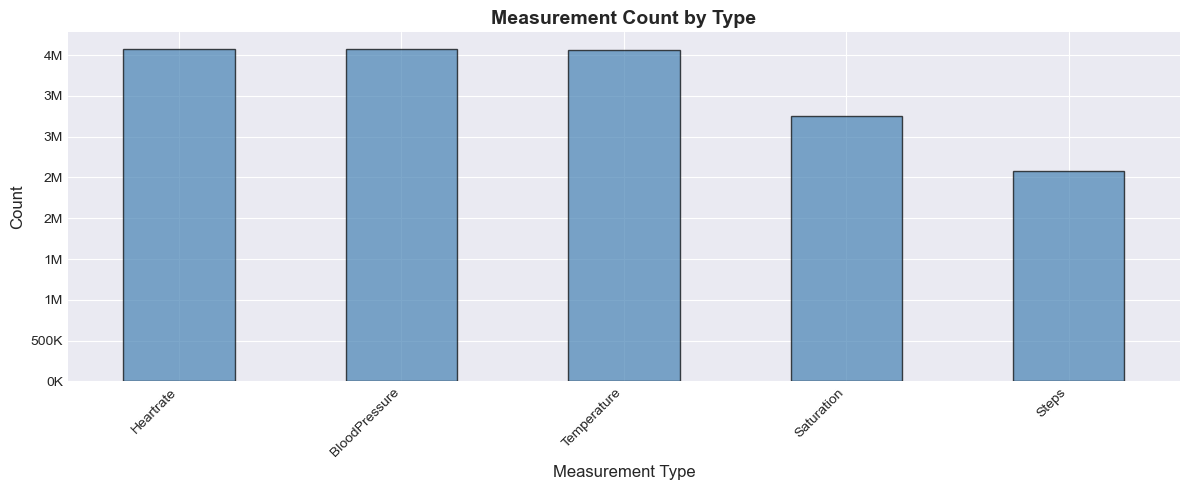

✓ Plot saved: 01_measurement_counts_by_type.png


In [16]:
# Count measurements by type
measurement_counts = df_measurements['type'].value_counts().sort_values(ascending=False)

print("\n" + "="*60)
print("MEASUREMENT COUNTS BY TYPE")
print("="*60)
print(measurement_counts)
print(f"\nTotal unique types: {df_measurements['type'].nunique()}")

# Create visualization
fig, ax = plt.subplots(figsize=(12, 5))
measurement_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('Measurement Count by Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Measurement Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e6)}M' if x >= 1e6 else f'{int(x/1e3)}K'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../plots/01_measurement_counts_by_type.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved: 01_measurement_counts_by_type.png")



DATE RANGE & TEMPORAL COVERAGE
Start date:     2025-11-10 00:00:00
End date:       2025-11-15 23:59:56
Date range:     5 days

Daily measurements statistics:
  Min: 2,777,109
  Max: 3,155,922
  Mean: 3,005,531
  Median: 3,017,582


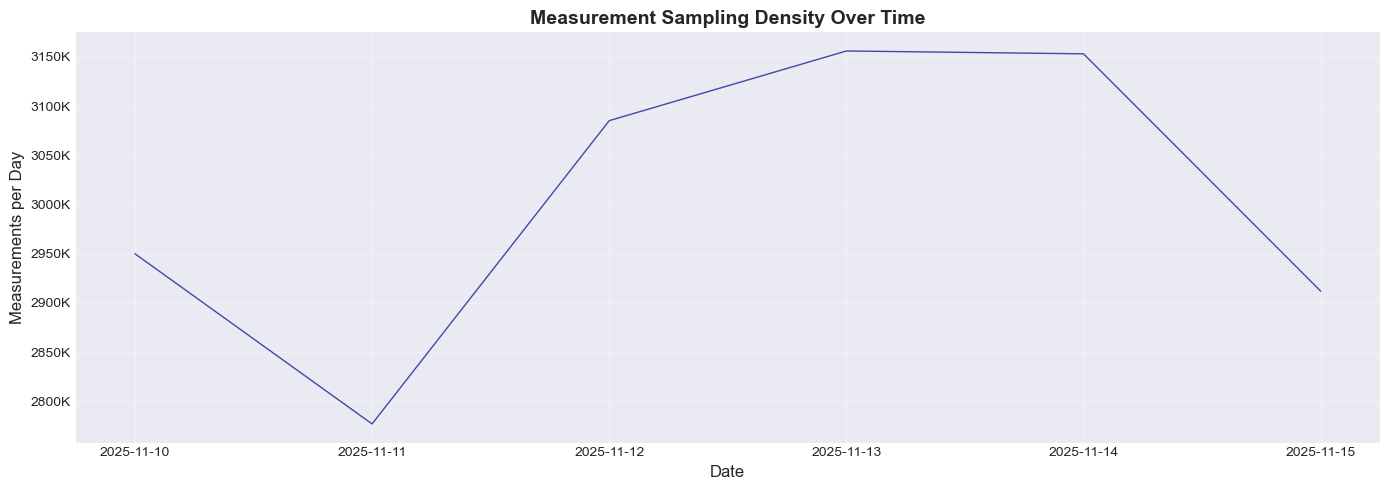

✓ Plot saved: 02_measurements_per_day_timeline.png


In [34]:
# Date range analysis
date_min = df_measurements['date'].min()
date_max = df_measurements['date'].max()
date_range_days = (date_max - date_min).days

print("\n" + "="*60)
print("DATE RANGE & TEMPORAL COVERAGE")
print("="*60)
print(f"Start date:     {date_min}")
print(f"End date:       {date_max}")
print(f"Date range:     {date_range_days} days")

# Measurements per day
df_measurements['measurement_date'] = df_measurements['date'].dt.date
measurements_per_day = df_measurements.groupby('measurement_date').size()

print("\nDaily measurements statistics:")
print(f"  Min: {measurements_per_day.min():,}")
print(f"  Max: {measurements_per_day.max():,}")
print(f"  Mean: {measurements_per_day.mean():,.0f}")
print(f"  Median: {measurements_per_day.median():,.0f}")

# Visualization: Measurements per day
fig, ax = plt.subplots(figsize=(14, 5))
measurements_per_day.plot(ax=ax, color='darkblue', alpha=0.7, linewidth=1)
ax.set_title('Measurement Sampling Density Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Measurements per Day', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e3)}K'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/02_measurements_per_day_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved: 02_measurements_per_day_timeline.png")


In [7]:
# Sampling frequency per measurement type
print("\n" + "="*60)
print("SAMPLING FREQUENCY BY MEASUREMENT TYPE")
print("="*60)

sampling_frequency = []

for mtype in df_measurements['type'].unique():
    df_type = df_measurements[df_measurements['type'] == mtype].copy()
    
    # Measurements per senior
    measurements_per_senior = df_type.groupby('senior_id').size()
    
    # Time span per senior (in days)
    time_span_per_senior = df_type.groupby('senior_id').apply(
        lambda x: (x['date'].max() - x['date'].min()).days
    )
    
    # Avoid division by zero
    time_span_per_senior = time_span_per_senior[time_span_per_senior > 0]
    
    if len(time_span_per_senior) > 0:
        # Sampling frequency (measurements per day)
        freq_per_senior = measurements_per_senior[time_span_per_senior.index] / (time_span_per_senior + 1)
        mean_freq = freq_per_senior.mean()
        median_freq = freq_per_senior.median()
    else:
        mean_freq = 0
        median_freq = 0
    
    sampling_frequency.append({
        'Type': mtype,
        'Count': len(df_type),
        'Unique Seniors': df_type['senior_id'].nunique(),
        'Mean Freq (meas/day)': mean_freq,
        'Median Freq (meas/day)': median_freq
    })

df_sampling = pd.DataFrame(sampling_frequency)
print(df_sampling.to_string(index=False))



SAMPLING FREQUENCY BY MEASUREMENT TYPE
         Type   Count  Unique Seniors  Mean Freq (meas/day)  Median Freq (meas/day)
  Temperature 4057151           11744             62.412744               49.000000
    Heartrate 4074735           11762             62.499752               49.000000
BloodPressure 4074731           11762             62.499589               49.000000
   Saturation 3250993           11708             50.186169               35.833333
        Steps 2575576           10168             51.826818               47.333333


## 3. Duplicates Analysis

In [9]:
# Duplicate detection in measurements based on (senior_id, date, type)
print("\n" + "="*60)
print("DUPLICATE ANALYSIS IN MEASUREMENTS")
print("="*60)

# Create a composite key
df_measurements['composite_key'] = df_measurements.apply(
    lambda x: (x['senior_id'], x['date'], x['type']), axis=1
)

# Find duplicates
duplicates = df_measurements[df_measurements.duplicated(subset=['composite_key'], keep=False)]

print(f"\nTotal duplicate records (including originals): {len(duplicates)}")
print(f"Unique (senior_id, date, type) combinations with duplicates: {duplicates['composite_key'].nunique()}")

if len(duplicates) > 0:
    print("\nFirst 20 duplicate records:")
    # Sort by composite key to group duplicates together
    duplicates_sorted = duplicates.sort_values(['senior_id', 'date', 'type']).head(20)
    print(duplicates_sorted[['senior_id', 'date', 'type', 'value', 'sbp', 'dbp', 'id']].to_string(index=False))
else:
    print("✓ No duplicates found")

# Count duplicates by type
if len(duplicates) > 0:
    print("\nDuplicates by measurement type:")
    dup_by_type = duplicates['type'].value_counts().sort_values(ascending=False)
    print(dup_by_type)



DUPLICATE ANALYSIS IN MEASUREMENTS

Total duplicate records (including originals): 434
Unique (senior_id, date, type) combinations with duplicates: 217

First 20 duplicate records:
 senior_id                date          type  value   sbp  dbp       id
      4442 2025-11-14 06:48:30 BloodPressure    NaN 120.0 78.0  8996080
      4442 2025-11-14 06:48:30 BloodPressure    NaN 111.0 76.0  8996084
      4442 2025-11-14 06:48:30     Heartrate   53.0   NaN  NaN  4904255
      4442 2025-11-14 06:48:30     Heartrate   54.0   NaN  NaN  4904259
      8708 2025-11-13 06:07:11 BloodPressure    NaN 131.0 78.0  8741142
      8708 2025-11-13 06:07:11 BloodPressure    NaN 121.0 78.0  8741154
      8708 2025-11-13 06:07:11     Heartrate   66.0   NaN  NaN  4648970
      8708 2025-11-13 06:07:11     Heartrate   68.0   NaN  NaN  4648982
      8709 2025-11-10 10:57:16 BloodPressure    NaN 122.0 79.0 10883803
      8709 2025-11-10 10:57:16 BloodPressure    NaN 120.0 85.0 10894345
      8709 2025-11-10 10:5

## 4. Distribution Analysis of Vital Signs

### 4.1 Heartrate Distribution

In [18]:
# Helper function for distribution analysis
def analyze_vital_sign(df, measurement_type, column, physiological_bounds=None, sampling=False):
    """
    Analyze distribution of a vital sign with optional physiological bounds checking.
    
    Parameters:
    -----------
    df : DataFrame
        Full measurements dataframe
    measurement_type : str
        Type of measurement to filter
    column : str
        Column to analyze ('value', 'sbp', 'dbp')
    physiological_bounds : tuple
        (min, max) for physiological bounds, e.g., (60, 100)
    """
    
    # Filter data for this measurement type
    df_type = df[df['type'] == measurement_type].copy()
    
    if len(df_type) == 0:
        print(f"⚠ No data for {measurement_type}")
        return None
    
    # Use all data or sample if too large
    if sampling:
        sample_idx = np.random.choice(len(df_type), 100000, replace=False)
        df_sample = df_type.iloc[sample_idx].copy()
        print(f"⚠ Sampled {len(df_sample):,} records from {len(df_type):,} total")
    else:
        df_sample = df_type.copy()
        print(f"Using {len(df_sample):,} records")
    
    # Get values
    values = df_sample[column].dropna()
    
    # Descriptive statistics
    stats = {
        'Mean': values.mean(),
        'Std': values.std(),
        'Min': values.min(),
        'Max': values.max(),
        '5th percentile': values.quantile(0.05),
        '25th percentile': values.quantile(0.25),
        '50th percentile': values.quantile(0.50),
        '75th percentile': values.quantile(0.75),
        '95th percentile': values.quantile(0.95),
    }
    
    # Physiological bounds check
    if physiological_bounds:
        min_phys, max_phys = physiological_bounds
        out_of_bounds = ((values < min_phys) | (values > max_phys)).sum()
        print(f"\nPhysiologically impossible values (outside {min_phys}-{max_phys}):")
        print(f"  Count: {out_of_bounds:,} ({out_of_bounds/len(values)*100:.2f}%)")
        
        if out_of_bounds > 0:
            print(f"  Range: {values[((values < min_phys) | (values > max_phys))].min():.1f} - {values[((values < min_phys) | (values > max_phys))].max():.1f}")
    
    return {
        'stats': stats,
        'values': values,
        'df_sample': df_sample,
        'bounds': physiological_bounds
    }


HEARTRATE ANALYSIS
Using 4,074,735 records

Physiologically impossible values (outside 20-220):
  Count: 0 (0.00%)

Descriptive Statistics:
  Mean                : 73.42
  Std                 : 17.81
  Min                 : 24.00
  Max                 : 205.00
  5th percentile      : 51.00
  25th percentile     : 58.00
  50th percentile     : 69.00
  75th percentile     : 90.00
  95th percentile     : 103.00


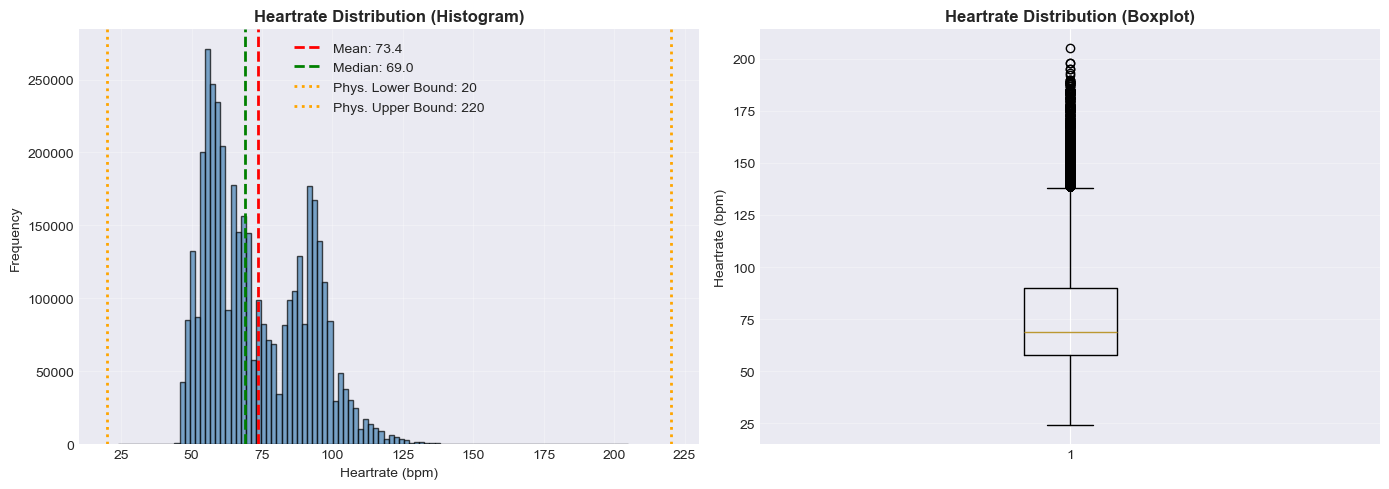


✓ Plot saved: 04_heartrate_distribution.png


In [21]:
# Analyze Heartrate
print("\n" + "="*60)
print("HEARTRATE ANALYSIS")
print("="*60)
hr_result = analyze_vital_sign(df_measurements, 'Heartrate', 'value', physiological_bounds=(20, 220))

if hr_result:
    print("\nDescriptive Statistics:")
    for key, val in hr_result['stats'].items():
        print(f"  {key:20}: {val:.2f}")

# Visualization: Heartrate
if hr_result:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(hr_result['values'], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(hr_result['stats']['Mean'], color='red', linestyle='--', linewidth=2, label=f"Mean: {hr_result['stats']['Mean']:.1f}")
    axes[0].axvline(hr_result['stats']['50th percentile'], color='green', linestyle='--', linewidth=2, label=f"Median: {hr_result['stats']['50th percentile']:.1f}")
    if hr_result['bounds']:
        axes[0].axvline(hr_result['bounds'][0], color='orange', linestyle=':', linewidth=2, label=f"Phys. Lower Bound: {hr_result['bounds'][0]}")
        axes[0].axvline(hr_result['bounds'][1], color='orange', linestyle=':', linewidth=2, label=f"Phys. Upper Bound: {hr_result['bounds'][1]}")
    axes[0].set_title('Heartrate Distribution (Histogram)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Heartrate (bpm)')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Boxplot
    axes[1].boxplot(hr_result['values'], vert=True)
    axes[1].set_title('Heartrate Distribution (Boxplot)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Heartrate (bpm)')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('../plots/04_heartrate_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Plot saved: 04_heartrate_distribution.png")


### 4.2 Temperature Distribution


TEMPERATURE ANALYSIS
Using 4,057,151 records

Physiologically impossible values (outside 34-42):
  Count: 5,585 (0.14%)
  Range: 42.1 - 127.9

Descriptive Statistics:
  Mean                : 36.72
  Std                 : 3.21
  Min                 : 36.30
  Max                 : 127.90
  5th percentile      : 36.30
  25th percentile     : 36.60
  50th percentile     : 36.60
  75th percentile     : 36.70
  95th percentile     : 36.80


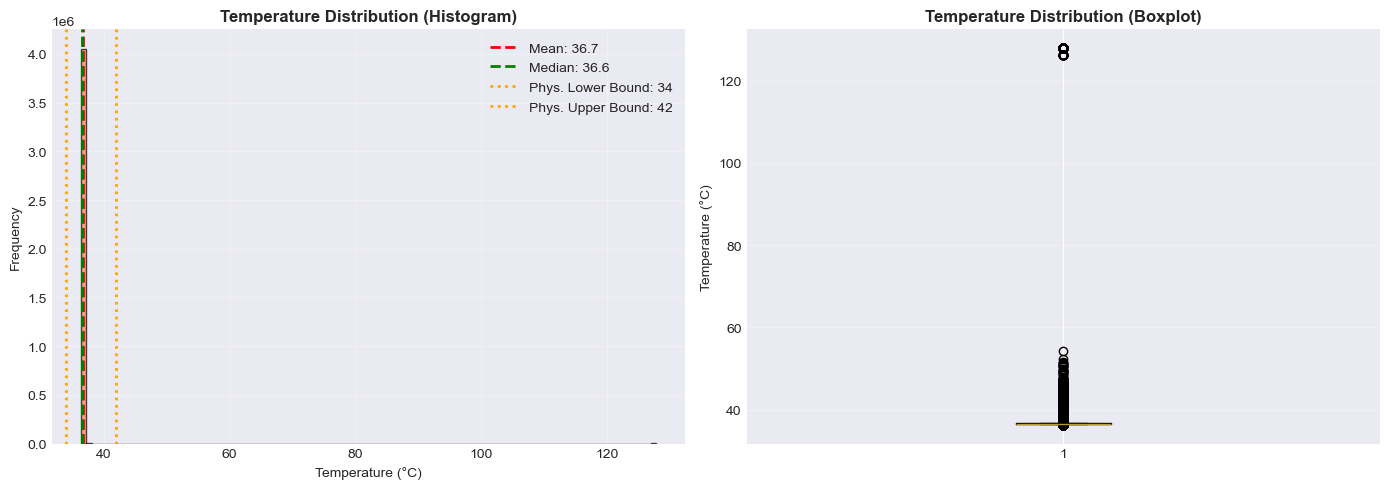


✓ Plot saved: 05_temperature_distribution.png


In [22]:
# Analyze Temperature
print("\n" + "="*60)
print("TEMPERATURE ANALYSIS")
print("="*60)
temp_result = analyze_vital_sign(df_measurements, 'Temperature', 'value', physiological_bounds=(34, 42))

if temp_result:
    print("\nDescriptive Statistics:")
    for key, val in temp_result['stats'].items():
        print(f"  {key:20}: {val:.2f}")

# Visualization: Temperature
if temp_result:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(temp_result['values'], bins=100, color='coral', edgecolor='black', alpha=0.7)
    axes[0].axvline(temp_result['stats']['Mean'], color='red', linestyle='--', linewidth=2, label=f"Mean: {temp_result['stats']['Mean']:.1f}")
    axes[0].axvline(temp_result['stats']['50th percentile'], color='green', linestyle='--', linewidth=2, label=f"Median: {temp_result['stats']['50th percentile']:.1f}")
    if temp_result['bounds']:
        axes[0].axvline(temp_result['bounds'][0], color='orange', linestyle=':', linewidth=2, label=f"Phys. Lower Bound: {temp_result['bounds'][0]}")
        axes[0].axvline(temp_result['bounds'][1], color='orange', linestyle=':', linewidth=2, label=f"Phys. Upper Bound: {temp_result['bounds'][1]}")
    axes[0].set_title('Temperature Distribution (Histogram)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Temperature (°C)')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Boxplot
    axes[1].boxplot(temp_result['values'], vert=True)
    axes[1].set_title('Temperature Distribution (Boxplot)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Temperature (°C)')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('../plots/05_temperature_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Plot saved: 05_temperature_distribution.png")


### 4.3 SpO₂ (Oxygen Saturation) Distribution


SpO2 (OXYGEN SATURATION) ANALYSIS
Using 3,250,993 records

Physiologically impossible values (outside 70-100):
  Count: 0 (0.00%)

Descriptive Statistics:
  Mean                : 97.08
  Std                 : 3.29
  Min                 : 80.00
  Max                 : 99.00
  5th percentile      : 91.00
  25th percentile     : 97.00
  50th percentile     : 98.00
  75th percentile     : 99.00
  95th percentile     : 99.00


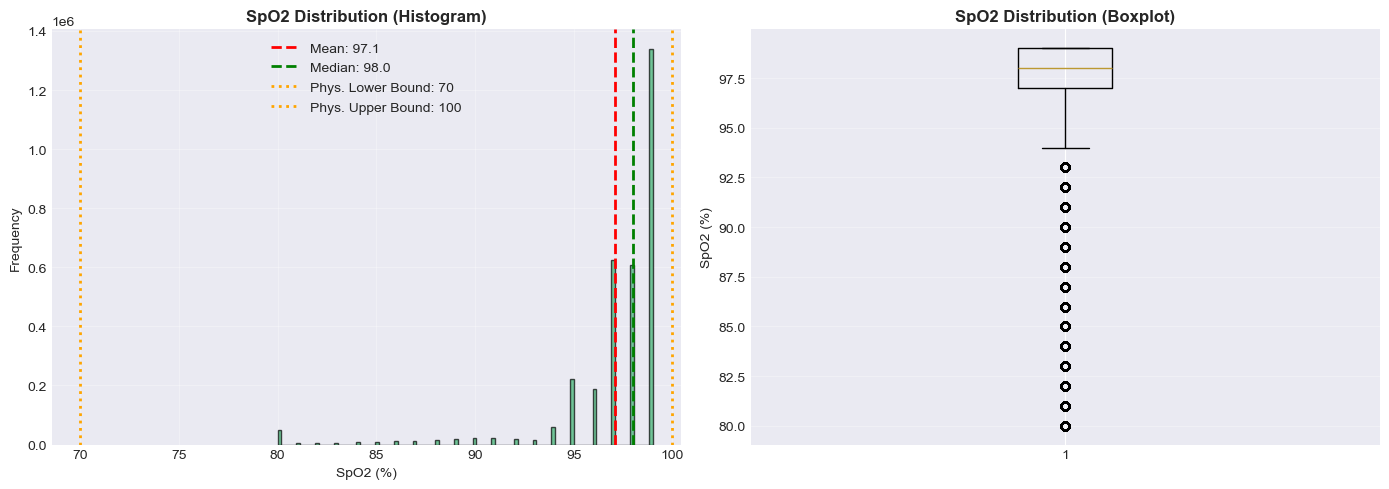


✓ Plot saved: 06_spo2_distribution.png


In [25]:
# Analyze SpO2
print("\n" + "="*60)
print("SpO2 (OXYGEN SATURATION) ANALYSIS")
print("="*60)
saturation_result = analyze_vital_sign(df_measurements, 'Saturation', 'value', physiological_bounds=(70, 100))

if saturation_result:
    print("\nDescriptive Statistics:")
    for key, val in saturation_result['stats'].items():
        print(f"  {key:20}: {val:.2f}")

# Visualization: SpO2
if saturation_result:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(saturation_result['values'], bins=100, color='mediumseagreen', edgecolor='black', alpha=0.7)
    axes[0].axvline(saturation_result['stats']['Mean'], color='red', linestyle='--', linewidth=2, label=f"Mean: {saturation_result['stats']['Mean']:.1f}")
    axes[0].axvline(saturation_result['stats']['50th percentile'], color='green', linestyle='--', linewidth=2, label=f"Median: {saturation_result['stats']['50th percentile']:.1f}")
    if saturation_result['bounds']:
        axes[0].axvline(saturation_result['bounds'][0], color='orange', linestyle=':', linewidth=2, label=f"Phys. Lower Bound: {saturation_result['bounds'][0]}")
        axes[0].axvline(saturation_result['bounds'][1], color='orange', linestyle=':', linewidth=2, label=f"Phys. Upper Bound: {saturation_result['bounds'][1]}")
    axes[0].set_title('SpO2 Distribution (Histogram)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('SpO2 (%)')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Boxplot
    axes[1].boxplot(saturation_result['values'], vert=True)
    axes[1].set_title('SpO2 Distribution (Boxplot)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('SpO2 (%)')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('../plots/06_spo2_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Plot saved: 06_spo2_distribution.png")


### 4.4 Steps Distribution


STEPS ANALYSIS
Using 2,575,576 records

Physiologically impossible values (outside 0-50000):
  Count: 0 (0.00%)

Descriptive Statistics:
  Mean                : 3173.54
  Std                 : 3206.62
  Min                 : 1.00
  Max                 : 36955.00
  5th percentile      : 104.00
  25th percentile     : 783.00
  50th percentile     : 2198.00
  75th percentile     : 4562.00
  95th percentile     : 9528.00


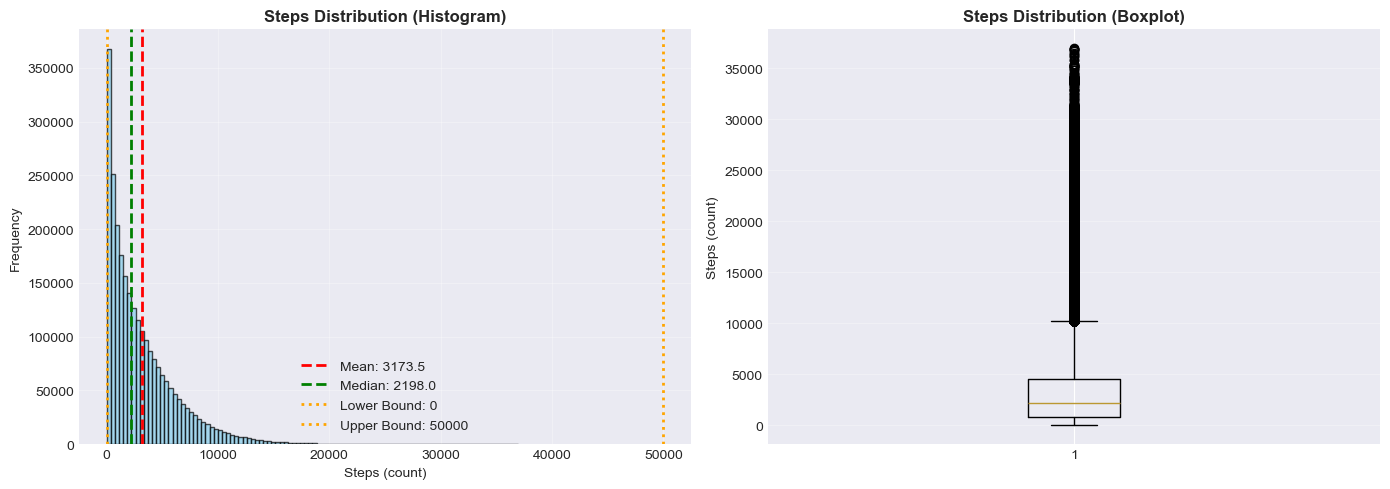


✓ Plot saved: 07_steps_distribution.png


In [24]:
# Analyze Steps
print("\n" + "="*60)
print("STEPS ANALYSIS")
print("="*60)
steps_result = analyze_vital_sign(df_measurements, 'Steps', 'value', physiological_bounds=(0, 50000))

if steps_result:
    print("\nDescriptive Statistics:")
    for key, val in steps_result['stats'].items():
        print(f"  {key:20}: {val:.2f}")

# Visualization: Steps
if steps_result:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(steps_result['values'], bins=100, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(steps_result['stats']['Mean'], color='red', linestyle='--', linewidth=2, label=f"Mean: {steps_result['stats']['Mean']:.1f}")
    axes[0].axvline(steps_result['stats']['50th percentile'], color='green', linestyle='--', linewidth=2, label=f"Median: {steps_result['stats']['50th percentile']:.1f}")
    if steps_result['bounds']:
        axes[0].axvline(steps_result['bounds'][0], color='orange', linestyle=':', linewidth=2, label=f"Lower Bound: {steps_result['bounds'][0]}")
        axes[0].axvline(steps_result['bounds'][1], color='orange', linestyle=':', linewidth=2, label=f"Upper Bound: {steps_result['bounds'][1]}")
    axes[0].set_title('Steps Distribution (Histogram)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Steps (count)')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Boxplot
    axes[1].boxplot(steps_result['values'], vert=True)
    axes[1].set_title('Steps Distribution (Boxplot)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Steps (count)')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('../plots/07_steps_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Plot saved: 07_steps_distribution.png")


### 4.5 Blood Pressure (SBP & DBP) Distribution


BLOOD PRESSURE ANALYSIS
Using 4,074,731 records

--- Systolic Blood Pressure (SBP) ---
  Mean                : 129.39
  Std                 : 11.85
  Min                 : 68.00
  Max                 : 212.00
  5th percentile      : 111.00
  50th percentile     : 129.00
  95th percentile     : 148.00

Physiologically impossible SBP (outside 70-220 mmHg):
  Count: 79 (0.00%)

--- Diastolic Blood Pressure (DBP) ---
  Mean                : 78.62
  Std                 : 8.87
  Min                 : 23.00
  Max                 : 156.00
  5th percentile      : 62.00
  50th percentile     : 79.00
  95th percentile     : 92.00

Physiologically impossible DBP (outside 40-130 mmHg):
  Count: 1,537 (0.04%)


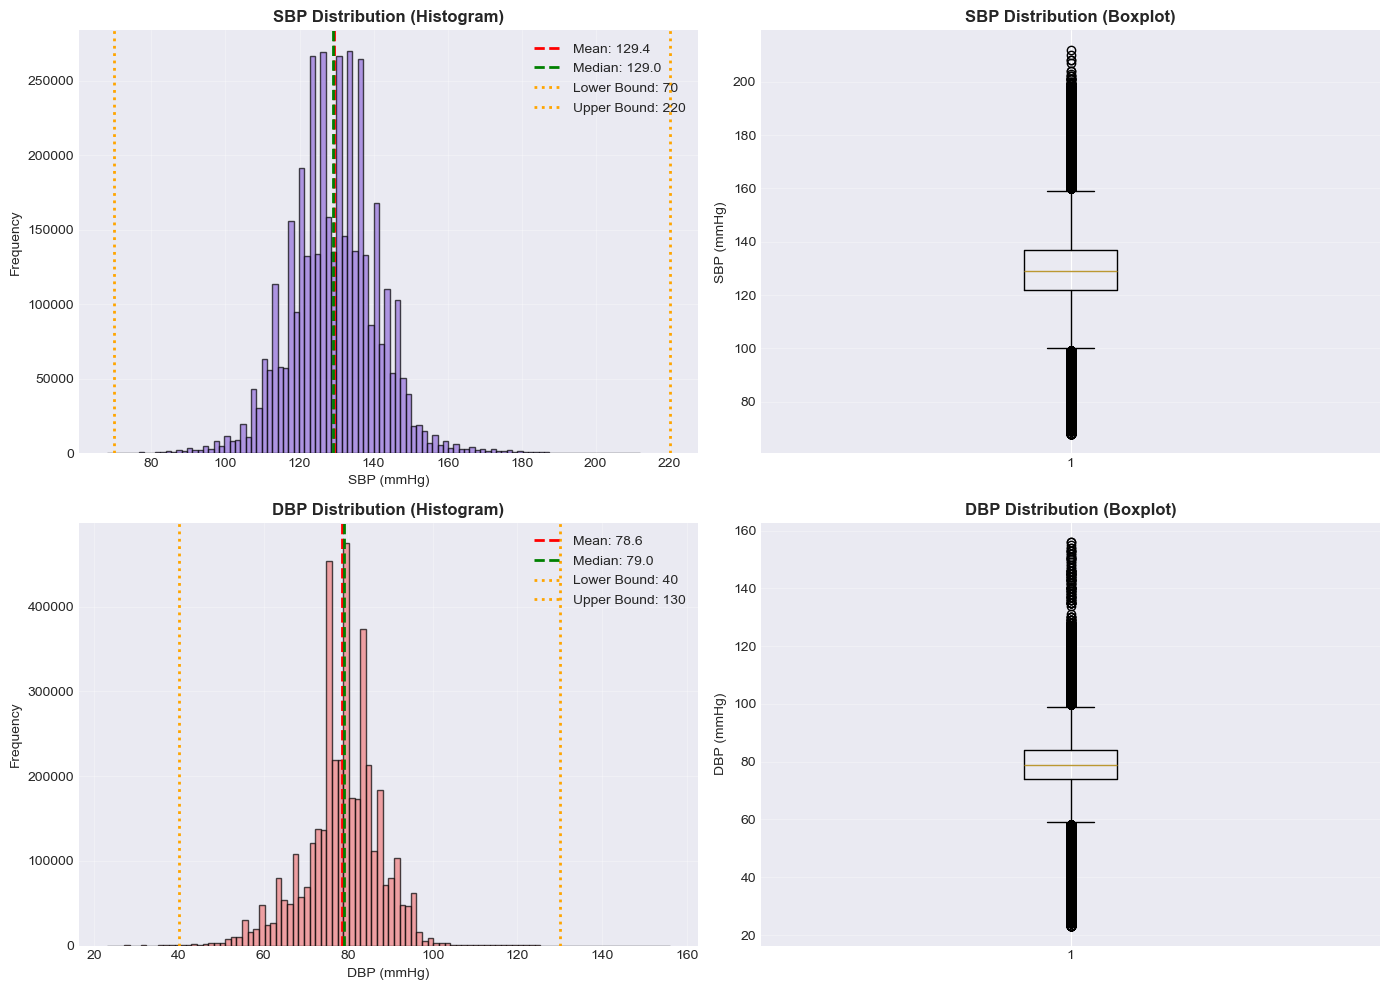


✓ Plot saved: 08_blood_pressure_distribution.png


In [27]:
# Analyze Blood Pressure (SBP and DBP)
print("\n" + "="*60)
print("BLOOD PRESSURE ANALYSIS")
print("="*60)

sampling = False  # Set to True to sample 100,000 records for large datasets

# Get BloodPressure measurements
df_bp = df_measurements[df_measurements['type'] == 'BloodPressure'].copy()


if sampling:
    sample_idx = np.random.choice(len(df_bp), 100000, replace=False)
    df_bp_sample = df_bp.iloc[sample_idx].copy()
    print(f"⚠ Sampled {len(df_bp_sample):,} records from {len(df_bp):,} total")
else:
    df_bp_sample = df_bp.copy()
    print(f"Using {len(df_bp_sample):,} records")

# Systolic Blood Pressure (SBP)
print("\n--- Systolic Blood Pressure (SBP) ---")
sbp_values = df_bp_sample['sbp'].dropna()
sbp_stats = {
    'Mean': sbp_values.mean(),
    'Std': sbp_values.std(),
    'Min': sbp_values.min(),
    'Max': sbp_values.max(),
    '5th percentile': sbp_values.quantile(0.05),
    '50th percentile': sbp_values.quantile(0.50),
    '95th percentile': sbp_values.quantile(0.95),
}

for key, val in sbp_stats.items():
    print(f"  {key:20}: {val:.2f}")

# Check physiological bounds for SBP (typically 70-220 mmHg)
sbp_out_of_bounds = ((sbp_values < 70) | (sbp_values > 220)).sum()
print("\nPhysiologically impossible SBP (outside 70-220 mmHg):")
print(f"  Count: {sbp_out_of_bounds:,} ({sbp_out_of_bounds/len(sbp_values)*100:.2f}%)")

# Diastolic Blood Pressure (DBP)
print("\n--- Diastolic Blood Pressure (DBP) ---")
dbp_values = df_bp_sample['dbp'].dropna()
dbp_stats = {
    'Mean': dbp_values.mean(),
    'Std': dbp_values.std(),
    'Min': dbp_values.min(),
    'Max': dbp_values.max(),
    '5th percentile': dbp_values.quantile(0.05),
    '50th percentile': dbp_values.quantile(0.50),
    '95th percentile': dbp_values.quantile(0.95),
}

for key, val in dbp_stats.items():
    print(f"  {key:20}: {val:.2f}")

# Check physiological bounds for DBP (typically 40-130 mmHg)
dbp_out_of_bounds = ((dbp_values < 40) | (dbp_values > 130)).sum()
print("\nPhysiologically impossible DBP (outside 40-130 mmHg):")
print(f"  Count: {dbp_out_of_bounds:,} ({dbp_out_of_bounds/len(dbp_values)*100:.2f}%)")

# Visualization: Blood Pressure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# SBP Histogram
axes[0, 0].hist(sbp_values, bins=100, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(sbp_stats['Mean'], color='red', linestyle='--', linewidth=2, label=f"Mean: {sbp_stats['Mean']:.1f}")
axes[0, 0].axvline(sbp_stats['50th percentile'], color='green', linestyle='--', linewidth=2, label=f"Median: {sbp_stats['50th percentile']:.1f}")
axes[0, 0].axvline(70, color='orange', linestyle=':', linewidth=2, label="Lower Bound: 70")
axes[0, 0].axvline(220, color='orange', linestyle=':', linewidth=2, label="Upper Bound: 220")
axes[0, 0].set_title('SBP Distribution (Histogram)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('SBP (mmHg)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# SBP Boxplot
axes[0, 1].boxplot(sbp_values, vert=True)
axes[0, 1].set_title('SBP Distribution (Boxplot)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('SBP (mmHg)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# DBP Histogram
axes[1, 0].hist(dbp_values, bins=100, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(dbp_stats['Mean'], color='red', linestyle='--', linewidth=2, label=f"Mean: {dbp_stats['Mean']:.1f}")
axes[1, 0].axvline(dbp_stats['50th percentile'], color='green', linestyle='--', linewidth=2, label=f"Median: {dbp_stats['50th percentile']:.1f}")
axes[1, 0].axvline(40, color='orange', linestyle=':', linewidth=2, label="Lower Bound: 40")
axes[1, 0].axvline(130, color='orange', linestyle=':', linewidth=2, label="Upper Bound: 130")
axes[1, 0].set_title('DBP Distribution (Histogram)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('DBP (mmHg)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# DBP Boxplot
axes[1, 1].boxplot(dbp_values, vert=True)
axes[1, 1].set_title('DBP Distribution (Boxplot)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('DBP (mmHg)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../plots/08_blood_pressure_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Plot saved: 08_blood_pressure_distribution.png")


## 5. Time-Series Structure & Sampling Analysis

### 5.1 Time Gaps Analysis

In [30]:
# Helper function to compute time gaps
def compute_time_gaps(df_type, sample_size=10000, sampling=False):
    """
    Compute time gaps for measurements of a specific type per senior.
    
    Parameters:
    -----------
    df_type : DataFrame
        Filtered measurements for a single type
    sample_size : int
        Max number of records to use (for efficiency)
    
    Returns:
    --------
    dict with 'gaps' (list of gaps in hours), 'n_seniors', 'n_records'
    """
    
    if sampling and len(df_type) > sample_size:
        sample_idx = np.random.choice(len(df_type), sample_size, replace=False)
        df_sample = df_type.iloc[sample_idx].copy()
    else:
        df_sample = df_type.copy()
    
    all_gaps = []
    
    # Group by senior_id and compute gaps
    for senior_id, group in df_sample.groupby('senior_id'):
        # Sort by date
        sorted_group = group.sort_values('date')
        dates = sorted_group['date'].values
        
        # Compute gaps between consecutive measurements (in hours)
        if len(dates) > 1:
            gaps_hours = np.diff(dates) / np.timedelta64(1, 'h')
            all_gaps.extend(gaps_hours)
    
    return {
        'gaps': all_gaps,
        'n_seniors': df_sample['senior_id'].nunique(),
        'n_records': len(df_sample)
    }

print("\n" + "="*60)
print("TIME GAPS ANALYSIS")
print("="*60)

time_gaps_results = {}

for mtype in df_measurements['type'].unique():
    df_type = df_measurements[df_measurements['type'] == mtype].copy()
    
    print(f"\n{mtype}:")
    result = compute_time_gaps(df_type, sample_size=10000)
    gaps = np.array(result['gaps'])
    
    print(f"  Records sampled: {result['n_records']:,}")
    print(f"  Unique seniors in sample: {result['n_seniors']}")
    print(f"  Total gaps computed: {len(gaps):,}")
    
    if len(gaps) > 0:
        print("  Gap statistics (hours):")
        print(f"    Mean: {gaps.mean():.2f}h ({gaps.mean()/24:.2f}d)")
        print(f"    Median: {np.median(gaps):.2f}h ({np.median(gaps)/24:.2f}d)")
        print(f"    Std: {gaps.std():.2f}h")
        print(f"    Min: {gaps.min():.2f}h")
        print(f"    Max: {gaps.max():.2f}h ({gaps.max()/24:.2f}d)")
        print(f"    95th percentile: {np.percentile(gaps, 95):.2f}h ({np.percentile(gaps, 95)/24:.2f}d)")
    
    time_gaps_results[mtype] = result



TIME GAPS ANALYSIS

Temperature:
  Records sampled: 4,057,151
  Unique seniors in sample: 11744
  Total gaps computed: 4,045,407
  Gap statistics (hours):
    Mean: 0.35h (0.01d)
    Median: 0.17h (0.01d)
    Std: 1.59h
    Min: 0.00h
    Max: 137.80h (5.74d)
    95th percentile: 0.67h (0.03d)

Heartrate:
  Records sampled: 4,074,735
  Unique seniors in sample: 11762
  Total gaps computed: 4,062,973
  Gap statistics (hours):
    Mean: 0.35h (0.01d)
    Median: 0.17h (0.01d)
    Std: 1.59h
    Min: 0.00h
    Max: 137.80h (5.74d)
    95th percentile: 0.67h (0.03d)

BloodPressure:
  Records sampled: 4,074,731
  Unique seniors in sample: 11762
  Total gaps computed: 4,062,969
  Gap statistics (hours):
    Mean: 0.35h (0.01d)
    Median: 0.17h (0.01d)
    Std: 1.59h
    Min: 0.00h
    Max: 137.80h (5.74d)
    95th percentile: 0.67h (0.03d)

Saturation:
  Records sampled: 3,250,993
  Unique seniors in sample: 11708
  Total gaps computed: 3,239,285
  Gap statistics (hours):
    Mean: 0.44h (

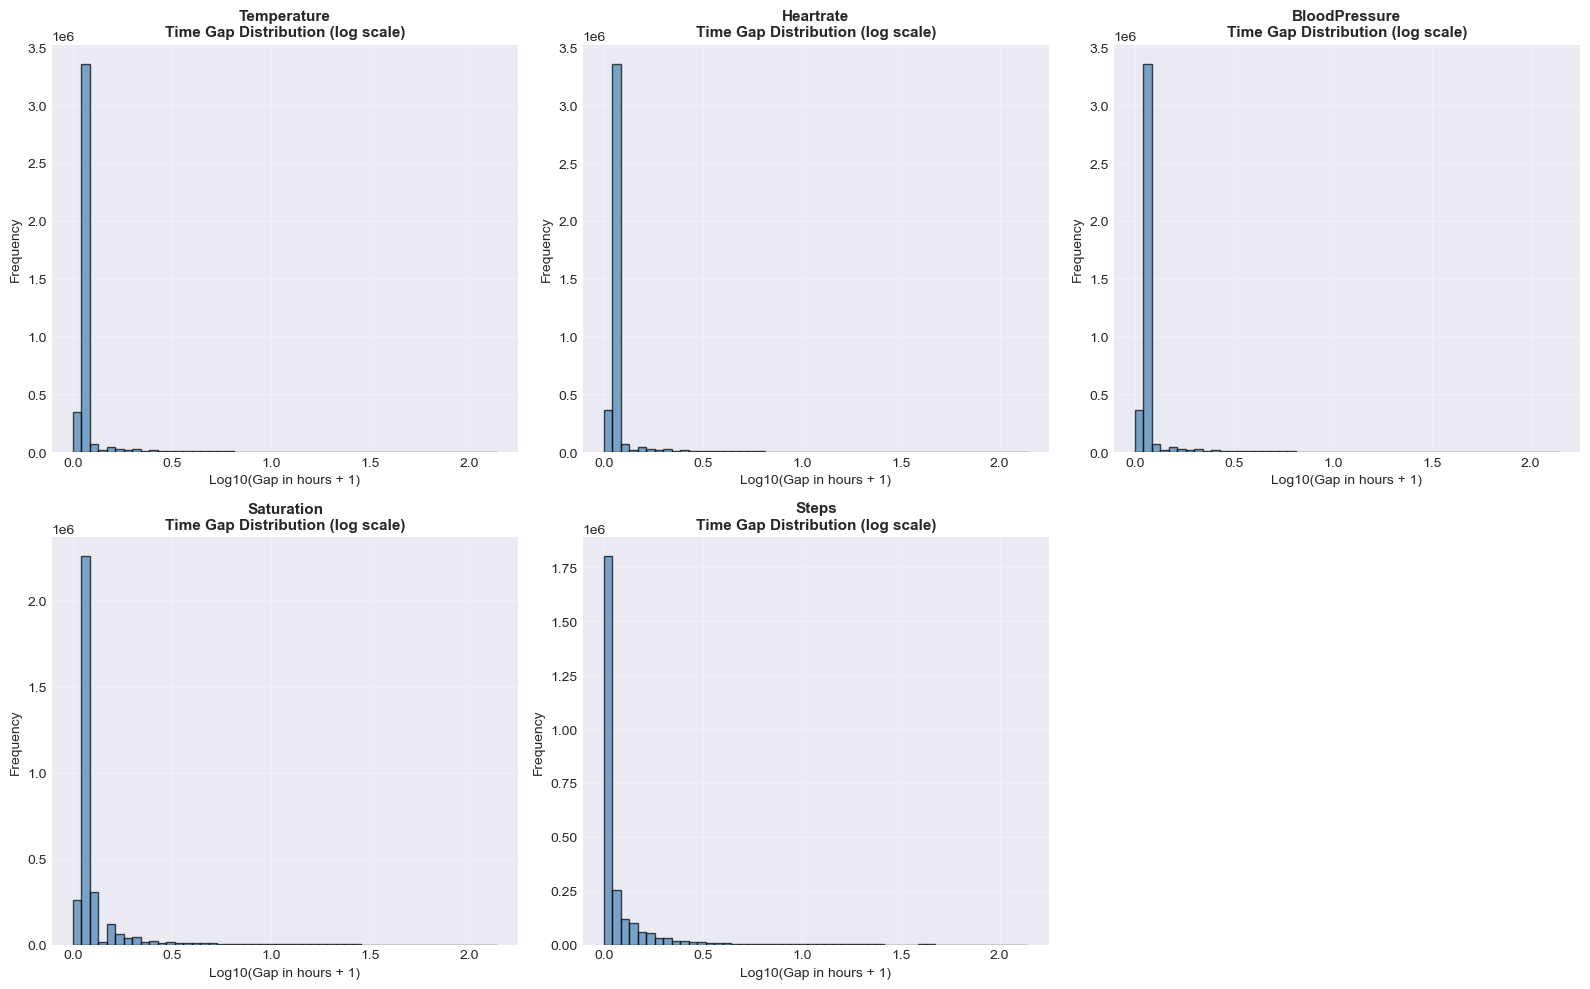


✓ Plot saved: 09_time_gaps_distribution.png


In [31]:
# Visualization: Time gaps distribution
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

measurement_types = list(time_gaps_results.keys())

for idx, mtype in enumerate(measurement_types):
    result = time_gaps_results[mtype]
    gaps = np.array(result['gaps'])
    
    if len(gaps) > 0:
        # Use log scale for better visibility (gaps can span from minutes to months)
        axes[idx].hist(np.log10(gaps + 1), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{mtype}\nTime Gap Distribution (log scale)', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Log10(Gap in hours + 1)')
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3)

# Remove unused subplots
if len(measurement_types) < len(axes):
    for idx in range(len(measurement_types), len(axes)):
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('../plots/09_time_gaps_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Plot saved: 09_time_gaps_distribution.png")


### 5.2 Time-Series Examples (Random Seniors)


TIME-SERIES EXAMPLES


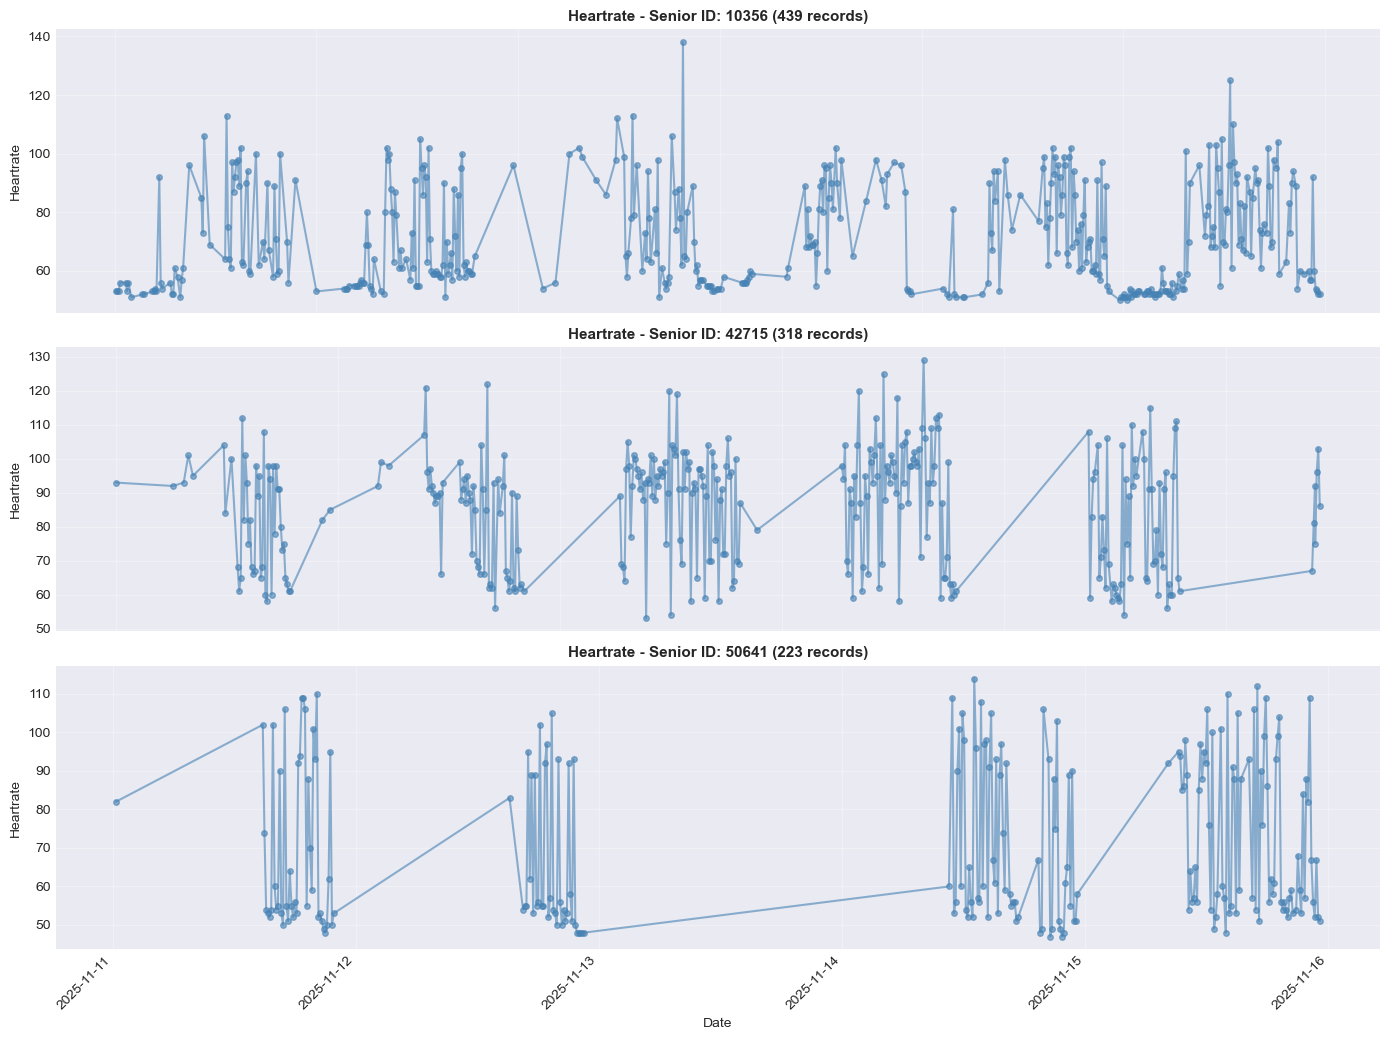

✓ Plot saved: 10_timeseries_heartrate.png


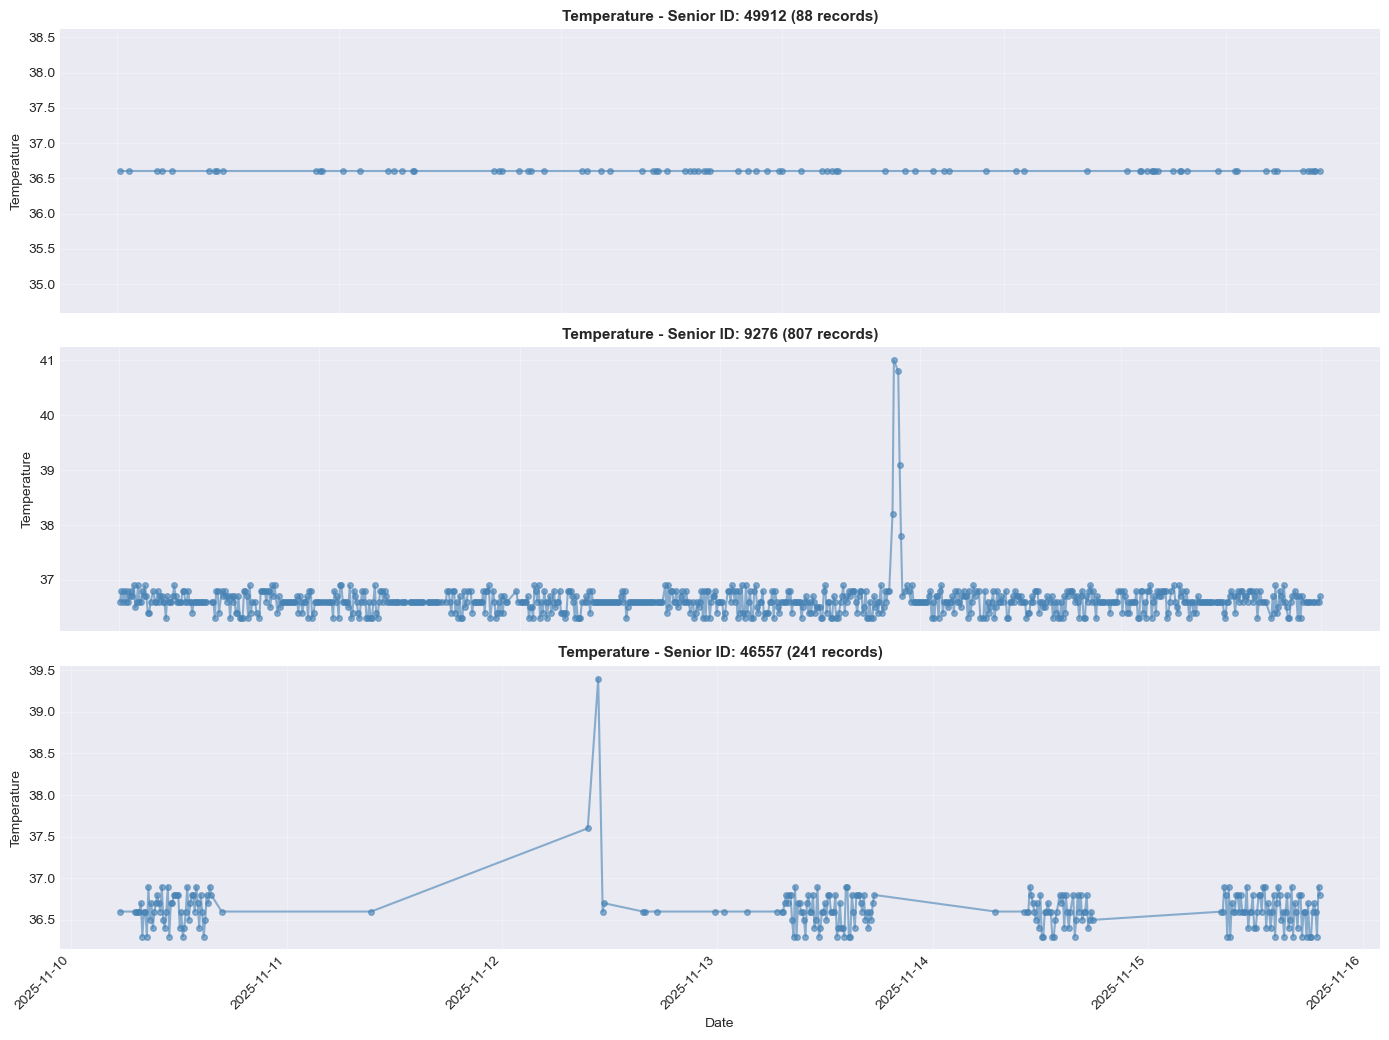

✓ Plot saved: 11_timeseries_temperature.png


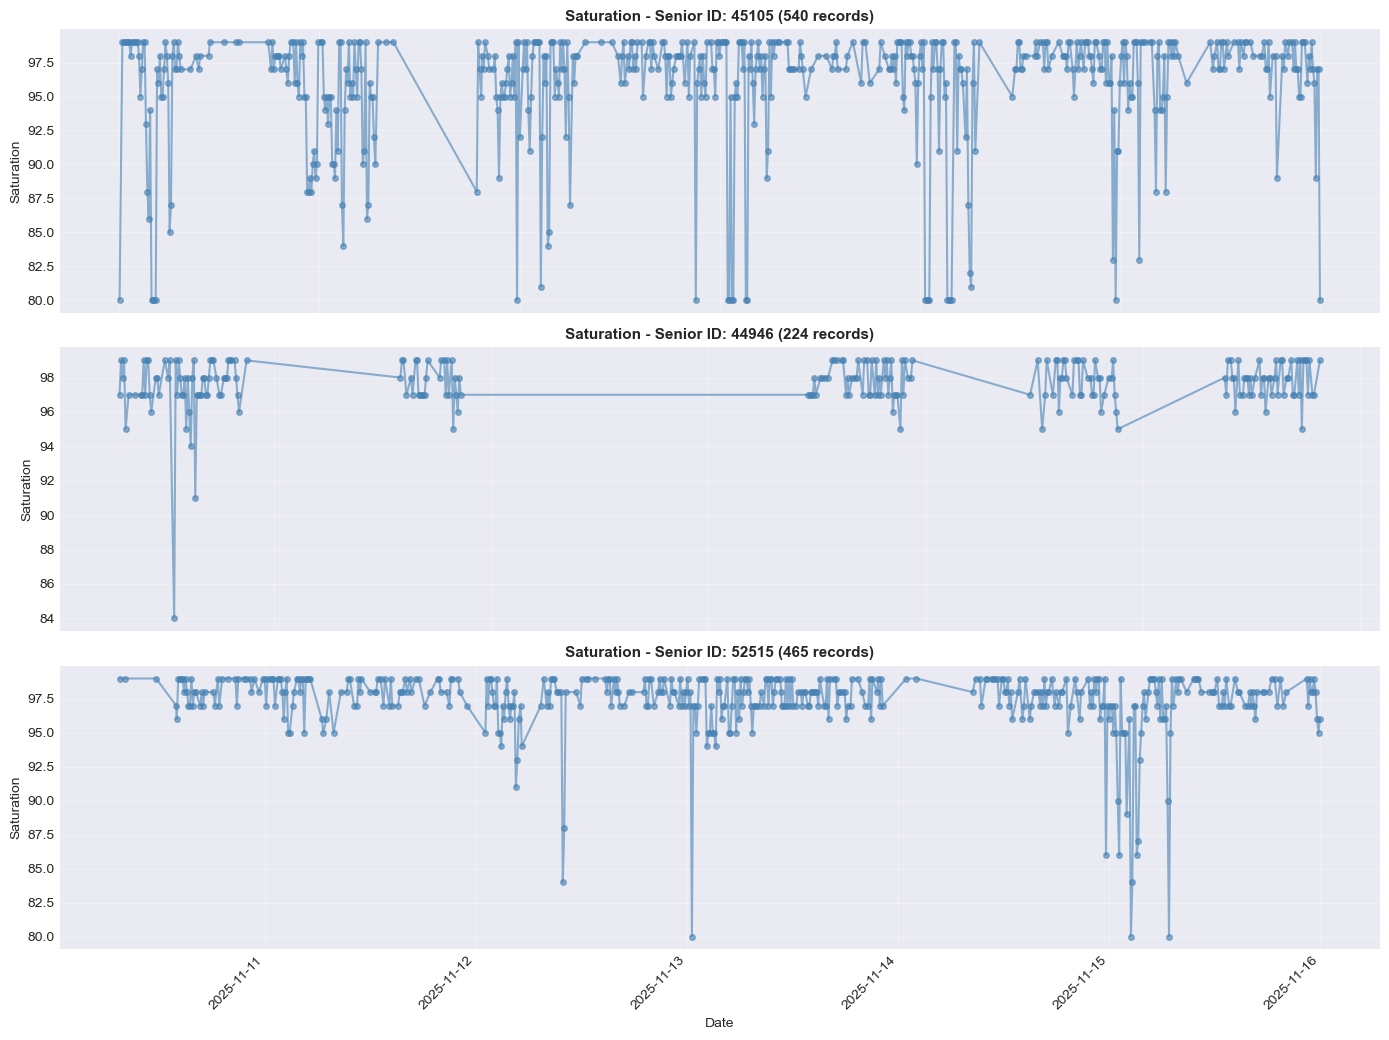

✓ Plot saved: 12_timeseries_spo2.png


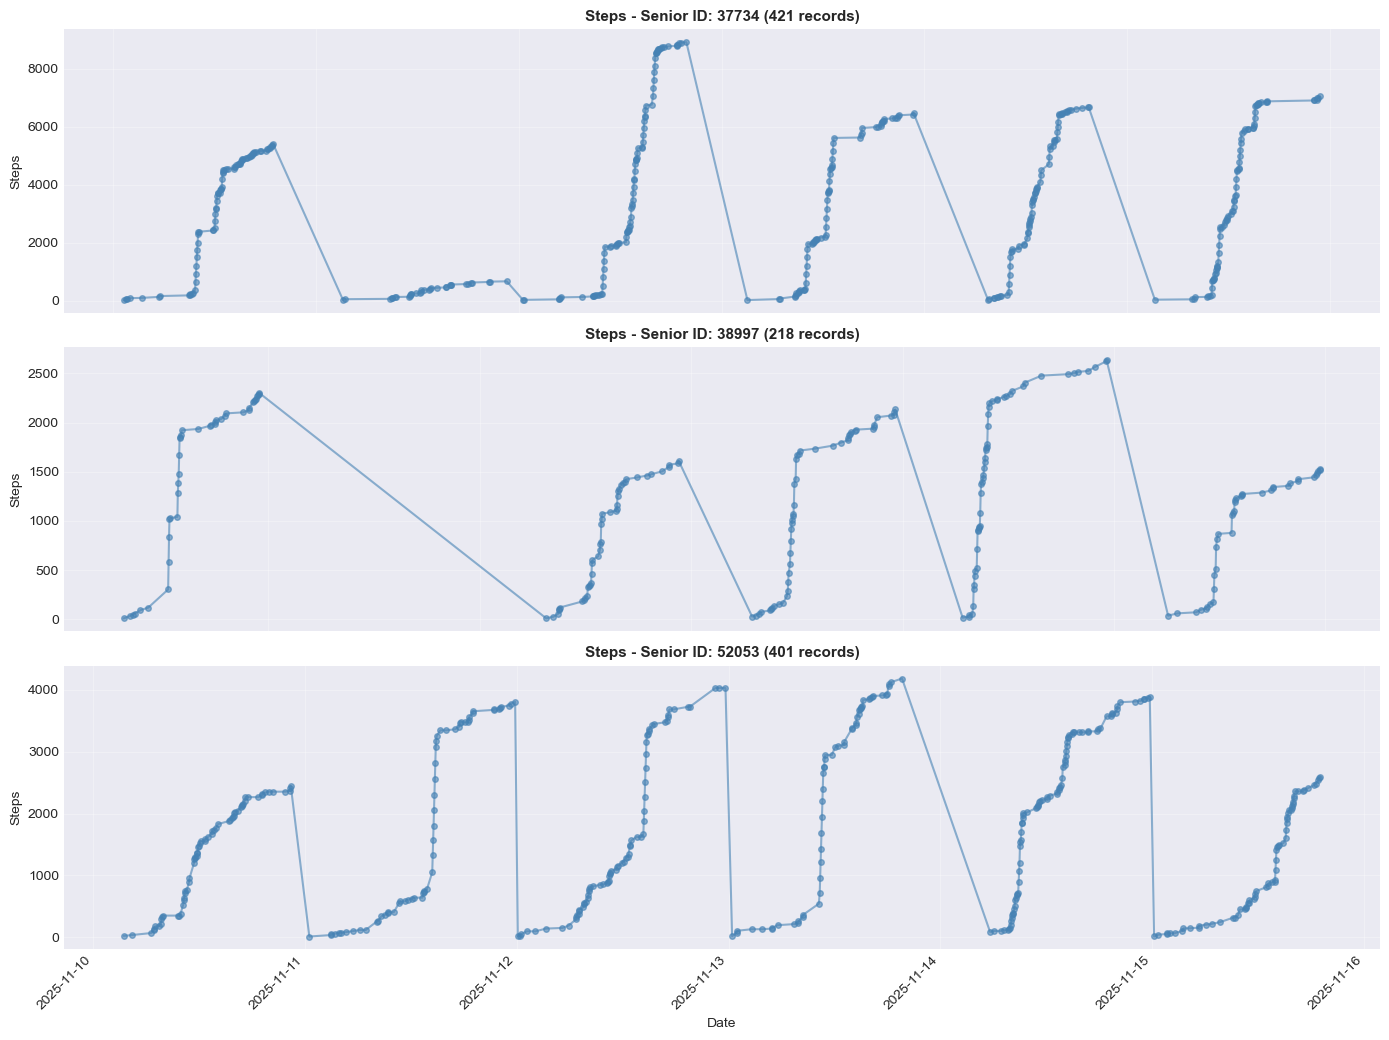

✓ Plot saved: 13_timeseries_steps.png


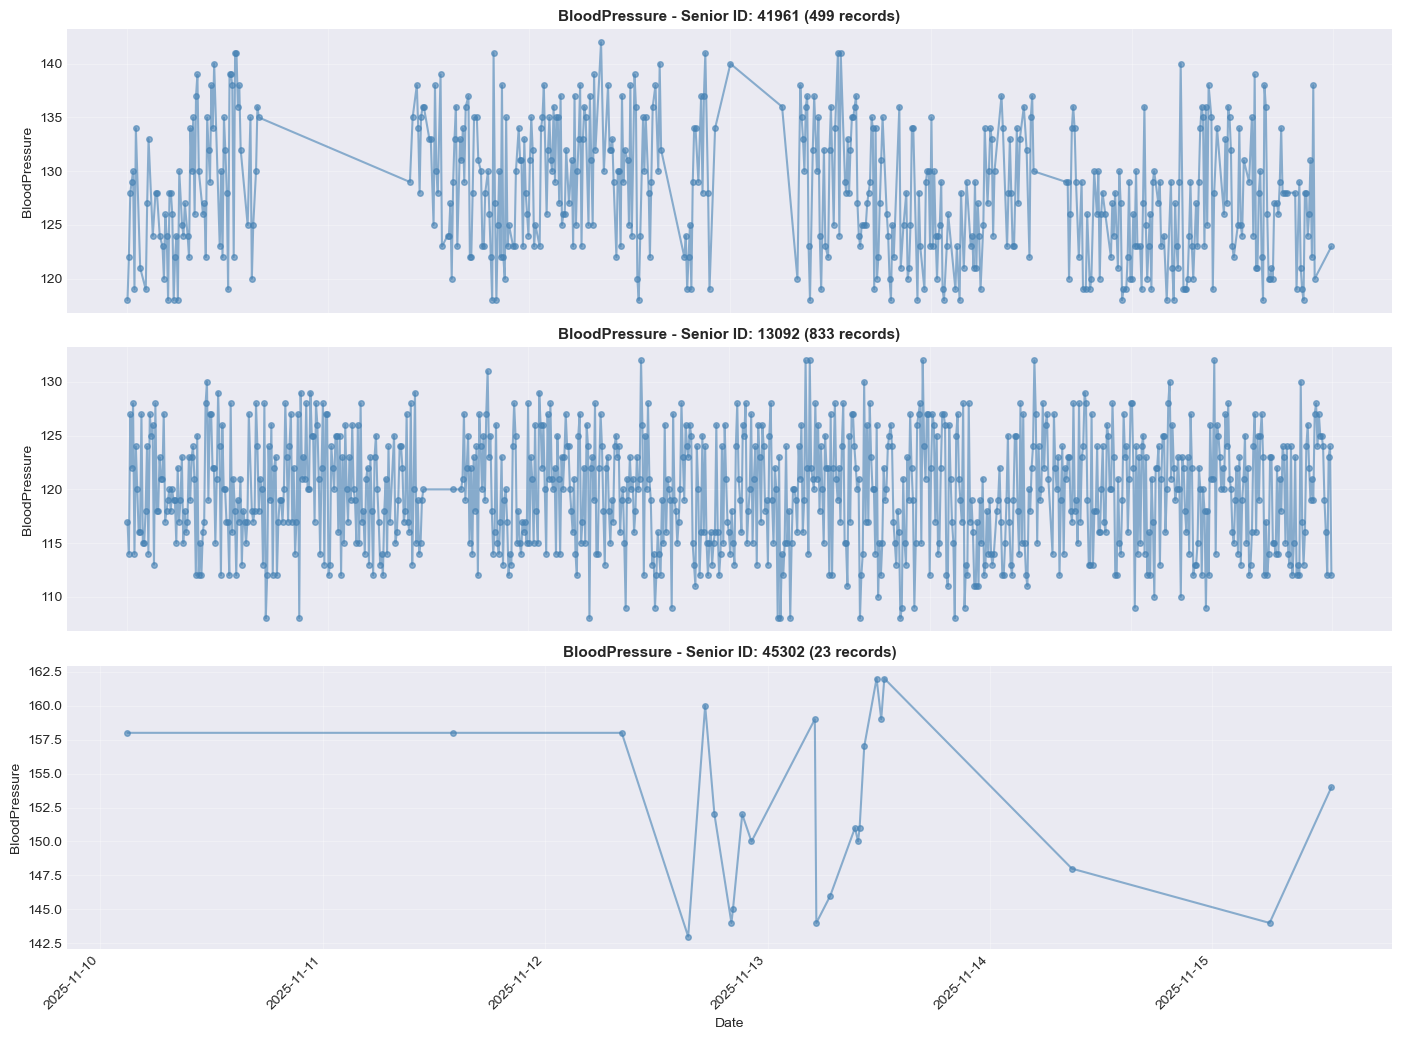

✓ Plot saved: 14_timeseries_sbp.png


In [32]:
# Function to plot time-series examples
def plot_timeseries_examples(df, measurement_type, column, n_seniors=3, max_records_per_senior=5000):
    """
    Plot time-series examples for random seniors of a specific measurement type.
    
    Parameters:
    -----------
    df : DataFrame
        Measurements dataframe
    measurement_type : str
        Type of measurement to plot
    column : str
        Column to use ('value', 'sbp', or 'dbp')
    n_seniors : int
        Number of random seniors to show
    max_records_per_senior : int
        Max records per senior to avoid overwhelming plots
    """
    
    df_type = df[df['type'] == measurement_type].copy()
    
    if len(df_type) == 0:
        print(f"No data for {measurement_type}")
        return None
    
    # Get unique seniors
    seniors = df_type['senior_id'].unique()
    random_seniors = np.random.choice(seniors, size=min(n_seniors, len(seniors)), replace=False)
    
    fig, axes = plt.subplots(n_seniors, 1, figsize=(14, 3.5*n_seniors))
    if n_seniors == 1:
        axes = [axes]
    
    for idx, senior_id in enumerate(random_seniors):
        df_senior = df_type[df_type['senior_id'] == senior_id].copy()
        
        # Sample if too many records
        if len(df_senior) > max_records_per_senior:
            df_senior = df_senior.sample(n=max_records_per_senior).sort_values('date')
        else:
            df_senior = df_senior.sort_values('date')
        
        # Plot
        axes[idx].plot(df_senior['date'], df_senior[column], 'o-', markersize=4, alpha=0.6, color='steelblue')
        axes[idx].set_title(f'{measurement_type} - Senior ID: {senior_id} ({len(df_senior)} records)', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Date')
        axes[idx].set_ylabel(measurement_type)
        axes[idx].grid(True, alpha=0.3)
        
        # Format x-axis
        fig.autofmt_xdate(rotation=45, ha='right')
    
    plt.tight_layout()
    return fig

print("\n" + "="*60)
print("TIME-SERIES EXAMPLES")
print("="*60)

# Plot examples for each measurement type
plot_configs = [
    ('Heartrate', 'value', '10_timeseries_heartrate.png'),
    ('Temperature', 'value', '11_timeseries_temperature.png'),
    ('Saturation', 'value', '12_timeseries_spo2.png'),
    ('Steps', 'value', '13_timeseries_steps.png'),
    ('BloodPressure', 'sbp', '14_timeseries_sbp.png'),
]

for mtype, column, filename in plot_configs:
    fig = plot_timeseries_examples(df_measurements, mtype, column, n_seniors=3)
    if fig:
        plt.savefig(f'../plots/{filename}', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ Plot saved: {filename}")
    else:
        print(f"⚠ Skipped {mtype} (no data)")


## 6. Cross-Feature Relationships

This section merges vitals on nearest timestamps (10-minute tolerance), builds a unified dataframe of HR, SBP, DBP, Temp, SpO₂, and Steps, computes a correlation matrix, plots a heatmap, and generates key scatterplots (HR vs BP, BP vs SpO₂, HR vs Steps).

In [10]:
# Cross-Feature Relationships: Nearest-timestamp merges + Correlations + Scatterplots
os.makedirs('../plots', exist_ok=True)
os.makedirs('../artifacts', exist_ok=True)

In [11]:
# Ensure df_measurements is available and dates are datetime
def ensure_measurements_loaded():
    global df_measurements
    try:
        _ = df_measurements.shape
    except NameError:
        print("df_measurements not found; loading from DB...")
        import sqlite3
        DB_PATH = '../db/hrp_data.db'
        conn_local = sqlite3.connect(DB_PATH)
        df_measurements = pd.read_sql_query("SELECT * FROM measurements", conn_local)
        conn_local.close()
    # Coerce date
    df_measurements['date'] = pd.to_datetime(df_measurements['date'])

ensure_measurements_loaded()

In [14]:
# Helper: get rows by a list of type aliases
def get_by_types(df, aliases):
    aliases_norm = [a.lower() for a in aliases]
    t = df['type'].astype(str).str.lower()
    return df[t.isin(aliases_norm)].copy()

# Build typed frames (supporting common aliases)
df_hr    = get_by_types(df_measurements, ['heartrate','heart rate','hr'])
df_temp  = get_by_types(df_measurements, ['temperature','temp'])
df_spo2  = get_by_types(df_measurements, ['spo2','spO2','spO₂','saturation'])
df_steps = get_by_types(df_measurements, ['steps','stepcount','step count'])
df_bp    = get_by_types(df_measurements, ['bloodpressure','blood pressure','bp'])

# Narrow columns and sort
if len(df_hr):
    df_hr   = df_hr[['senior_id','date','value']].rename(columns={'value':'hr'}).sort_values(['senior_id','date'])
if len(df_temp):
    df_temp = df_temp[['senior_id','date','value']].rename(columns={'value':'temp'}).sort_values(['senior_id','date'])
if len(df_spo2):
    df_spo2 = df_spo2[['senior_id','date','value']].rename(columns={'value':'spo2'}).sort_values(['senior_id','date'])
if len(df_steps):
    df_steps= df_steps[['senior_id','date','value']].rename(columns={'value':'steps'}).sort_values(['senior_id','date'])
if len(df_bp):
    df_bp   = df_bp[['senior_id','date','sbp','dbp']].sort_values(['senior_id','date'])

In [15]:
# Sample seniors for efficiency
seniors_all = df_measurements['senior_id'].dropna().unique()
np.random.seed(42)
sample_seniors = np.random.choice(seniors_all, size=min(300, len(seniors_all)), replace=False)

In [17]:
# Merge-nearest per senior with 10-minute tolerance
tolerance = pd.Timedelta('10min')
merged_rows = []

def merge_nearest_for_senior(sid):
    # 1. Get all unique timestamps for this senior across all vitals
    # This ensures we don't 'miss' a BP reading just because there was no HR reading
    hr_s = df_hr[df_hr['senior_id']==sid]
    bp_s = df_bp[df_bp['senior_id']==sid]
    
    if len(hr_s) == 0 and len(bp_s) == 0:
        return None

    # Use the union of HR and BP timestamps as our timeline
    all_times = pd.concat([hr_s[['date']], bp_s[['date']]]).drop_duplicates().sort_values('date')
    
    # Limit for speed if necessary
    if len(all_times) > 5000:
        all_times = all_times.sample(5000, random_state=42).sort_values('date')

    out = all_times

    # Merge everything onto this master timeline
    for right_df, cols in [
        (hr_s[['date','hr']], ['hr']),
        (bp_s[['date','sbp','dbp']], ['sbp','dbp']),
        (df_steps[df_steps['senior_id']==sid][['date','steps']], ['steps']),
        (df_temp[df_temp['senior_id']==sid][['date','temp']], ['temp']),
        (df_spo2[df_spo2['senior_id']==sid][['date','spo2']], ['spo2']),
    ]:
        if len(right_df) > 0:
            out = pd.merge_asof(
                out, right_df.sort_values('date'),
                on='date', direction='nearest', tolerance=pd.Timedelta('2min') # Tighten tolerance
            )
    out['senior_id'] = sid
    return out


Correlation matrix:
          hr    sbp    dbp   temp   spo2  steps
hr     1.000  0.292  0.272 -0.009  0.195  0.073
sbp    0.292  1.000  0.259  0.000  0.045 -0.075
dbp    0.272  0.259  1.000  0.002  0.033  0.074
temp  -0.009  0.000  0.002  1.000 -0.012  0.001
spo2   0.195  0.045  0.033 -0.012  1.000  0.020
steps  0.073 -0.075  0.074  0.001  0.020  1.000


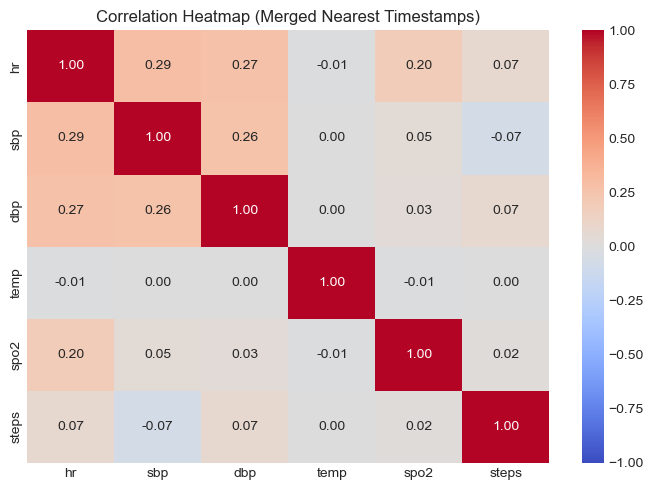

✓ Plot saved: 15_corr_heatmap_vitals.png


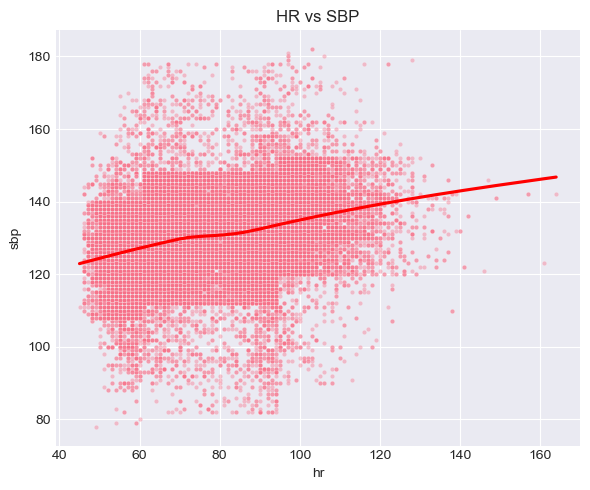

✓ Plot saved: 16_scatter_hr_vs_sbp.png


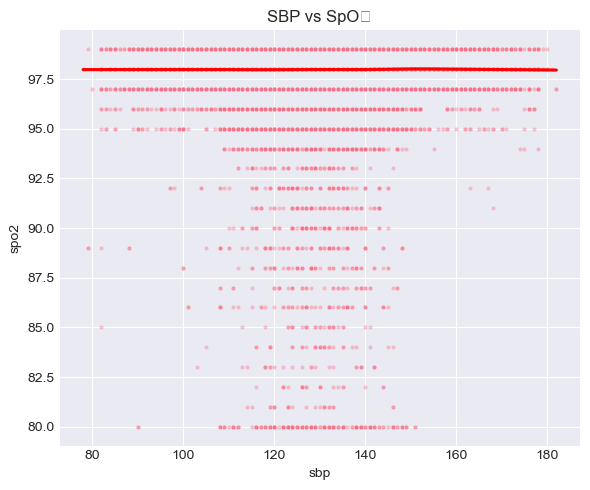

✓ Plot saved: 17_scatter_sbp_vs_spo2.png


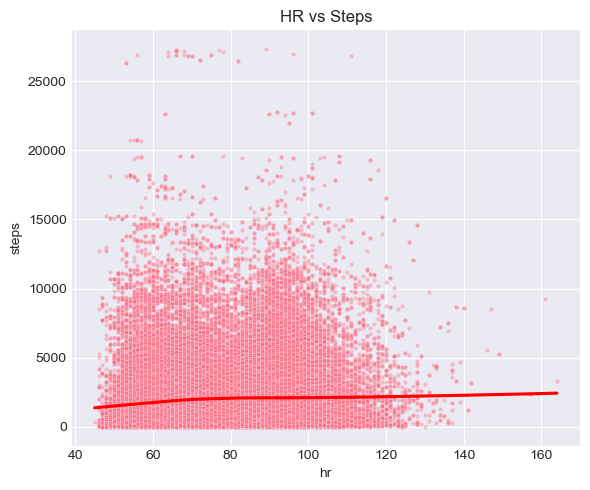

✓ Plot saved: 18_scatter_hr_vs_steps.png
✓ Saved correlation CSV: ../artifacts/correlation_vitals.csv


In [19]:
# Instead of using df_hr as the 'base', let's use a combined index of all times
for sid in sample_seniors:
    res = merge_nearest_for_senior(sid)
    if res is not None:
        merged_rows.append(res)

if merged_rows:
    df_merged_vitals = pd.concat(merged_rows, axis=0, ignore_index=True)
else:
    df_merged_vitals = pd.DataFrame(columns=['senior_id','date','hr','temp','spo2','steps','sbp','dbp'])

# Keep useful columns and drop rows missing HR
keep_cols = ['hr','sbp','dbp','temp','spo2','steps']
df_merged_vitals = df_merged_vitals.dropna(subset=['hr']).copy()

# Correlation matrix
if len(df_merged_vitals):
    corr = df_merged_vitals[keep_cols].corr(method='pearson')
    print("\nCorrelation matrix:")
    print(corr.round(3))

    # Heatmap
    plt.figure(figsize=(7,5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Correlation Heatmap (Merged Nearest Timestamps)')
    plt.tight_layout()
    plt.savefig('../plots/15_corr_heatmap_vitals.png', dpi=300)
    plt.show()
    print("✓ Plot saved: 15_corr_heatmap_vitals.png")

    # Scatterplots (sample up to 50k)
    pairs = [
        ('hr','sbp','16_scatter_hr_vs_sbp.png','HR vs SBP'),
        ('sbp','spo2','17_scatter_sbp_vs_spo2.png','SBP vs SpO₂'),
        ('hr','steps','18_scatter_hr_vs_steps.png','HR vs Steps')
    ]
    scatter_df = df_merged_vitals.dropna(subset=['hr','sbp','spo2','steps'])
    if len(scatter_df) > 50000:
        scatter_df = scatter_df.sample(50000, random_state=42)

    for x,y,fn,title in pairs:
        plt.figure(figsize=(6,5))
        sns.scatterplot(data=scatter_df, x=x, y=y, s=10, alpha=0.4)
        sns.regplot(data=scatter_df, x=x, y=y, scatter=False, color='red', lowess=True)
        plt.title(title)
        plt.tight_layout()
        plt.savefig(f'../plots/{fn}', dpi=300)
        plt.show()
        print(f"✓ Plot saved: {fn}")

    # Save correlation CSV
    corr.to_csv('../artifacts/correlation_vitals.csv')
    print("✓ Saved correlation CSV: ../artifacts/correlation_vitals.csv")
else:
    print("⚠ No merged data available (check measurement types and date parsing).")
